In [16]:
import os
from dotenv import load_dotenv
from pathlib import Path
import json
import numpy as np
import random
import re
from collections import Counter

load_dotenv()

# 로컬
ROOT = Path(os.environ["DATA_ROOT"])
HF_HOME = ROOT / ".hf_cache"
os.environ["HF_HOME"] = str(HF_HOME)

import torch
from transformers import AutoTokenizer
from datasets import load_dataset

In [17]:
# Config
config = {
    "seed": 42,
    "num_labels": 188,
    "splits": ["test", "val"],
    "raw_ds": "ingyoun/patent-clean-text",
    "fields": ["invention_title", "ipc_main", "abstract", "claims"],    # 기록용
    "hf_cache": str(HF_HOME),
    "out_path": ROOT / "output",

}

MODELS = [
    {
        "tag": "kobert-patent-baseline_len512",
        "arch": "kobert",
        "ckpt": "ingyoun/kobert-patent-baseline",
        "tokenizer": "monologg/kobert",
        "tok_rev": "38279184ba645e8c94d709fbe92eb5bcb47312c1",
        "token_ds": "ingyoun/patent-clean-text-kobert-tokenized",
        "max_len": None,           # 전처리(02_01)에서 이미 truncation=True, max_length=512로 잘려 올라갔다
        "batch_size": 8,
    },
    {
        "tag": "modernbert-patent-len512",
        "arch": "modernbert",
        "ckpt": "ingyoun/A.X-patent-maxlen512",
        "tokenizer": "skt/A.X-Encoder-base",
        "tok_rev": "9708f9c404ace91efd25c06fac2d73413616f4ef",
        "token_ds": "ingyoun/patent-clean-text-modernbert-tokenized",
        "max_len": 512,            # 토큰화 데이터셋은 절단 없이 올라가 있다 — 훈련 창으로 맞춘다
        "batch_size": 8,
    },
    {
        "tag": "roberta-patent-len512",
        "arch": "roberta-large",
        "ckpt": "ingyoun/roberta-patent-maxlen512",
        "tokenizer": "klue/roberta-large",
        "tok_rev": "28d911204e9022eda172571ca8cc61eaffd942f7",
        "token_ds": "ingyoun/patent-clean-text-roberta-tokenized",
        "max_len": 512,
        "batch_size": 8,
    },
]

In [3]:
# fix seed
random.seed(config["seed"])
np.random.seed(config["seed"])
torch.manual_seed(config["seed"])
torch.cuda.manual_seed_all(config["seed"])

In [4]:
print(torch.device("cuda" if torch.cuda.is_available() else "cpu"))

cpu


## 데이터셋, 토크나이저

In [ ]:
models_dict = {}
for m in MODELS:
    ds = load_dataset(m["token_ds"])
    kwargs = {"trust_remote_code": True} if m["arch"] == "kobert" else {}
    tok = AutoTokenizer.from_pretrained(m["tokenizer"], revision=m["tok_rev"], **kwargs)
    models_dict[m["arch"]] = {"dataset": ds, "tokenizer": tok}

In [9]:
models_dict.keys()

dict_keys(['kobert', 'modernbert', 'roberta-large'])

In [14]:
for k in models_dict.keys():
    print(k)

kobert
modernbert
roberta-large


In [10]:
def check_tokenizer(tokenizer, title: str):
    print(f"{title}")
    print(f"Vocab Size: {tokenizer.vocab_size}")
    print(f"Max Length: {tokenizer.model_max_length}")
    print(f"Max Length: {tokenizer.all_special_tokens}")

In [15]:
for k in models_dict.keys():
    check_tokenizer(models_dict[k]["tokenizer"], k)
    print("=" * 30)

kobert
Vocab Size: 8002
Max Length: 512
Max Length: ['[UNK]', '[SEP]', '[PAD]', '[CLS]', '[MASK]']
modernbert
Vocab Size: 49999
Max Length: 16384
Max Length: ['<s>', '<\\s>', '<unk>', '<sep>', '<pad>', '<cls>', '<mask>']
roberta-large
Vocab Size: 32000
Max Length: 512
Max Length: ['[CLS]', '[SEP]', '[UNK]', '[PAD]', '[MASK]']


## 입력 텍스트

baseline과 동일한 필드 조합(`invention_title + ipc_main + abstract + claims` 공백 join, 빈 필드 skip)

In [18]:
SPLIT = "test"          # 비교 축(3모델 bin 비교)과 정합 — 필요 시 "validation"으로 확장
WINDOW = 512            # baseline 창

raw = load_dataset(config["raw_ds"], split=SPLIT)

def build_input(ex) -> str:
    return " ".join(ex[f] for f in config["fields"] if ex[f])

texts = [build_input(ex) for ex in raw]
doc_ids = raw["document_id"]
kobert_len = np.array(raw["kobert_len"])
length_bin = np.array(raw["length_bin"])

print(f"{SPLIT}: {len(texts):,} docs")
print(f"문자 수 mean={np.mean([len(t) for t in texts]):,.0f}")
print("length_bin:", {b: int((length_bin == b).sum()) for b in ["<=512", "512-1024", "1024-2048", ">2048"]})

test: 11,271 docs
문자 수 mean=1,470
length_bin: {'<=512': 3197, '512-1024': 5183, '1024-2048': 2342, '>2048': 549}


## 공통 패스 — 어절 단위 토큰화

어절 경계는 원문 문자 위치(`re.finditer(r"\S+")`)로 직접 알수 있고, 조각 수는 세 토크나이저가 동일 규칙으로 센다. 어절별 조각 수 합이 문서 통째 토큰화와 **정확히 일치**하는 것을 아래 verify에서 보인다.

**coverage 정의**: 512 창에 조각이 전부 들어온 **마지막 어절의 끝 문자**까지를 도달 문자 수로 센다(경계에 걸친 어절은 제외)

In [20]:
WORD_RE = re.compile(r"\S+")

def analyze(tok, texts: list[str], window: int = WINDOW):
    """어절 단위 1패스. 문서별 배열 + 어절 조각 수의 전역 분포를 반환한다."""
    n_special = len(tok("")["input_ids"])       # 자동 부착되는 특수토큰 수(3종 모두 2)
    budget = window - n_special                 # 창에 실제로 담기는 본문 토큰 수
    unk_tok = tok.unk_token
    memo: dict[str, tuple[int, int]] = {}       # 어절 -> (조각 수, UNK 조각 수)
    frag = Counter()                            # 조각 수 -> 어절 빈도(전역)
    recs = []

    for text in texts:
        n_tok = n_unk = n_word = 0
        chars_in_window, fits = 0, True
        for m in WORD_RE.finditer(text):
            w = m.group()
            if w not in memo:
                pieces = tok.tokenize(w)
                memo[w] = (len(pieces), sum(p == unk_tok for p in pieces))
            k, u = memo[w]
            if fits:
                if n_tok + k <= budget:
                    chars_in_window = m.end()   # 완전히 담긴 마지막 어절의 끝
                else:
                    fits = False                # 이후 어절은 창 밖
            n_tok += k
            n_unk += u
            n_word += 1
            frag[k] += 1
        recs.append((n_tok + n_special, n_tok, n_unk, n_word, len(text), chars_in_window))

    cols = ["seq_len", "n_tok", "n_unk", "n_word", "n_char", "chars_in_window"]
    arr = {c: np.array([r[i] for r in recs]) for i, c in enumerate(cols)}
    return arr, frag, {"n_special": n_special, "budget": budget, "n_unique_words": len(memo)}


def stats(a) -> dict:
    a = np.asarray(a, dtype=float)
    return {
        "mean": round(float(a.mean()), 4),
        "p50": round(float(np.percentile(a, 50)), 4),
        "p90": round(float(np.percentile(a, 90)), 4),
        "p99": round(float(np.percentile(a, 99)), 4),
        "min": round(float(a.min()), 4),
        "max": round(float(a.max()), 4),
    }

In [21]:
%%time
A = {}
for k in models_dict:
    arr, frag, meta = analyze(models_dict[k]["tokenizer"], texts)
    A[k] = {"arr": arr, "frag": frag, "meta": meta}
    print(f"{k:14s} seq_len mean={arr['seq_len'].mean():7.1f}  budget={meta['budget']}  unique_words={meta['n_unique_words']:,}")

kobert         seq_len mean=  892.5  budget=510  unique_words=406,601
modernbert     seq_len mean=  804.2  budget=510  unique_words=406,601


[transformers] Token indices sequence length is longer than the specified maximum sequence length for this model (870 > 512). Running this sequence through the model will result in indexing errors


roberta-large  seq_len mean=  793.9  budget=510  unique_words=406,601
CPU times: total: 57.8 s
Wall time: 58.6 s


### verify

1. **어절 단위 == 문서 단위**: 어절별 조각 수의 합이 문서를 통째로 인코딩한 토큰 수와 같아야 한다.
2. **`kobert_len` 일치**: KoBERT `seq_len`이 데이터셋의 `kobert_len`(SSOT)과 전 문서 일치해야 한다.
3. **A.X−KoBERT 길이 차**: `docs/data/data.md`의 test 실측(mean +88.4, median +64, p90 +185, p99 +517)과 일치해야 한다.

In [22]:
# 1. 어절 단위 == 문서 단위 (표본 200)
for k in models_dict:
    tok = models_dict[k]["tokenizer"]
    docwise = np.array([len(tok(t, add_special_tokens=False)["input_ids"]) for t in texts[:200]])
    assert (A[k]["arr"]["n_tok"][:200] == docwise).all(), k
print("어절 단위 == 문서 단위: 3종 모두 일치 (200 docs)")

# 2. kobert_len(SSOT) 일치
mismatch = int((A["kobert"]["arr"]["seq_len"] != kobert_len).sum())
print(f"kobert_len 불일치: {mismatch} / {len(texts):,}")
assert mismatch == 0

# 3. A.X - KoBERT 길이 차 (양수 = A.X가 짧음) — data.md test 실측: mean +88.4 / median +64 / p90 +185 / p99 +517
diff = A["kobert"]["arr"]["seq_len"] - A["modernbert"]["arr"]["seq_len"]
print("kobert_len − A.X len:", stats(diff))

[transformers] Token indices sequence length is longer than the specified maximum sequence length for this model (1229 > 512). Running this sequence through the model will result in indexing errors


어절 단위 == 문서 단위: 3종 모두 일치 (200 docs)
kobert_len 불일치: 0 / 11,271
kobert_len − A.X len: {'mean': 88.3927, 'p50': 64.0, 'p90': 185.0, 'p99': 517.3, 'min': -1463.0, 'max': 2287.0}


## Fertility

토크나이저의 문서당 토큰수를 분포로 살펴본다. 
지표는 문자당 토큰 수(`n_tok / n_char`). 토크나이저 압축률을 직접 비교한다.

In [23]:
fertility = {}
for k in models_dict:
    a = A[k]["arr"]
    fertility[k] = {
        "vocab_size": models_dict[k]["tokenizer"].vocab_size,
        "tokens_per_char": stats(a["n_tok"] / a["n_char"]),
        "seq_len": stats(a["seq_len"]),
        "over_512_rate": round(float((a["seq_len"] > WINDOW).mean()), 4),
    }

print(f"{'':14s} {'vocab':>7s} {'tok/char':>9s} {'seq mean':>9s} {'p50':>7s} {'p90':>7s} {'p99':>7s} {'>512':>7s}")
for k, v in fertility.items():
    print(f"{k:14s} {v['vocab_size']:7,d} {v['tokens_per_char']['mean']:9.4f} "
          f"{v['seq_len']['mean']:9.1f} {v['seq_len']['p50']:7.0f} {v['seq_len']['p90']:7.0f} "
          f"{v['seq_len']['p99']:7.0f} {v['over_512_rate']:7.2%}")

# 문서별 길이 차 분포 — KoBERT 기준 (양수 = 해당 토크나이저가 짧음)
pairwise = {}
for k in ["modernbert", "roberta-large"]:
    d = A["kobert"]["arr"]["seq_len"] - A[k]["arr"]["seq_len"]
    pairwise[f"kobert_minus_{k}"] = stats(d)
    print(f"\nkobert − {k}: mean {d.mean():+.1f} / median {np.median(d):+.0f} "
          f"(A.X가 짧은 문서 {100 * (d > 0).mean():.1f}%)")

                 vocab  tok/char  seq mean     p50     p90     p99    >512
kobert           8,002    0.6045     892.5     703    1548    4212  71.64%
modernbert      49,999    0.5449     804.2     634    1383    3750  65.15%
roberta-large   32,000    0.5369     793.9     624    1368    3790  64.22%

kobert − modernbert: mean +88.4 / median +64 (A.X가 짧은 문서 93.4%)

kobert − roberta-large: mean +98.6 / median +74 (A.X가 짧은 문서 97.9%)


## Coverage

"A.X가 같은 512 창에 ~12% 더 많은 본문을 담는다"(재귀속의 커버리지 성분 ~+0.65pt의 기제)의 직접 실측이다. `coverage@512 = 창에 담긴 원문 문자 수 ÷ 전체 원문 문자 수`.

`kobert_len` bin별 분해가 핵심 판정이다 — 비교 문서는 모델 성분이 **종 모양**(B0 +0.34 → B1/B2 +1.3~1.4 → B3 +0.14)인 이유를 "B0은 절단이 없어 커버리지 우위가 무의미하고, B3는 너무 길어 A.X-512도 일부만 담아 우위가 사라진다"로 설명했다. 그 설명이 맞다면 **coverage 격차(A.X − KoBERT)도 B1·B2에서 최대인 종 모양**이어야 한다. 단조 증가하면 설명이 틀린 것이므로 재귀속을 다시 봐야 한다.

In [24]:
BINS = ["<=512", "512-1024", "1024-2048", ">2048"]

cov = {k: A[k]["arr"]["chars_in_window"] / A[k]["arr"]["n_char"] for k in models_dict}

coverage = {}
for k in models_dict:
    coverage[k] = {
        "overall": stats(cov[k]),
        "full_doc_rate": round(float((A[k]["arr"]["seq_len"] <= WINDOW).mean()), 4),   # 무손실 문서 비율
        "by_bin": {b: round(float(cov[k][length_bin == b].mean()), 4) for b in BINS},
    }

# "~12% 더 많은 본문"은 상대이득 — 절대 격차가 아니라 KoBERT 커버리지 대비 비율로 읽어야 한다.
print(f"{'bin':12s} {'n':>6s} " + " ".join(f"{k:>14s}" for k in models_dict) + f" {'Δ절대':>8s} {'Δ상대':>8s}")
for b in BINS:
    m = length_bin == b
    row = " ".join(f"{cov[k][m].mean():14.3f}" for k in models_dict)
    base, d = cov["kobert"][m].mean(), (cov["modernbert"][m] - cov["kobert"][m]).mean()
    print(f"{b:12s} {int(m.sum()):6,d} {row} {d:+8.3f} {100 * d / base:+7.1f}%")

d_all = cov["modernbert"] - cov["kobert"]
trunc = A["kobert"]["arr"]["seq_len"] > WINDOW        # KoBERT가 실제로 절단하는 문서 = 커버리지 우위가 작동할 수 있는 곳
print(f"\n전체 coverage: " + ", ".join(f"{k}={cov[k].mean():.4f}" for k in models_dict))
print(f"Δ(A.X−KoBERT) 전체:      {d_all.mean():+.4f} ({100 * d_all.mean() / cov['kobert'].mean():+.1f}%)")
print(f"Δ(A.X−KoBERT) 절단문서만: {d_all[trunc].mean():+.4f} ({100 * d_all[trunc].mean() / cov['kobert'][trunc].mean():+.1f}%)  n={int(trunc.sum()):,}")
print("무손실 문서 비율:", {k: f"{coverage[k]['full_doc_rate']:.2%}" for k in models_dict})

coverage["delta_ax_minus_kobert"] = {
    "overall_abs": round(float(d_all.mean()), 4),
    "overall_rel": round(float(d_all.mean() / cov["kobert"].mean()), 4),
    "truncated_only_abs": round(float(d_all[trunc].mean()), 4),
    "truncated_only_rel": round(float(d_all[trunc].mean() / cov["kobert"][trunc].mean()), 4),
    "by_bin_abs": {b: round(float((cov["modernbert"][length_bin == b] - cov["kobert"][length_bin == b]).mean()), 4) for b in BINS},
    "by_bin_rel": {b: round(float((cov["modernbert"][length_bin == b] - cov["kobert"][length_bin == b]).mean()
                                 / cov["kobert"][length_bin == b].mean()), 4) for b in BINS},
}

bin               n         kobert     modernbert  roberta-large      Δ절대      Δ상대
<=512         3,197          1.000          1.000          1.000   -0.000    -0.0%
512-1024      5,183          0.722          0.793          0.803   +0.070    +9.7%
1024-2048     2,342          0.394          0.438          0.444   +0.044   +11.2%
>2048           549          0.178          0.198          0.200   +0.020   +11.4%

전체 coverage: kobert=0.7064, modernbert=0.7488, roberta-large=0.7552
Δ(A.X−KoBERT) 전체:      +0.0424 (+6.0%)
Δ(A.X−KoBERT) 절단문서만: +0.0592 (+10.0%)  n=8,074
무손실 문서 비율: {'kobert': '28.36%', 'modernbert': '34.85%', 'roberta-large': '35.78%'}


## UNK ratio · 과분절

vocab 8,002의 표현 손실을 정량화한다. 두 신호를 함께 본다.

- **`[UNK]` 비율**: 전체 토큰 대비 · 문서별 분포 · UNK를 하나라도 가진 문서 비율.
- **과분절**: 어절당 서브워드 조각 수 분포와 3+ 조각 어절 비율.

이 둘이 B0(절단 없는 구간)의 순수 모델·토크나이저 품질차 +0.34pt를 설명하는 후보다 — 절단이 없어도 KoBERT가 지는 이유가 분절 품질이라면 여기에 신호가 있어야 한다.

In [25]:
degradation = {}
for k in models_dict:
    a, frag = A[k]["arr"], A[k]["frag"]
    n_words = sum(frag.values())
    degradation[k] = {
        "unk": {
            "rate_overall": round(float(a["n_unk"].sum() / a["n_tok"].sum()), 6),
            "doc_rate": stats(a["n_unk"] / a["n_tok"]),
            "docs_with_unk_rate": round(float((a["n_unk"] > 0).mean()), 4),
        },
        "pieces_per_word": {
            "mean": round(sum(kk * c for kk, c in frag.items()) / n_words, 4),
            "rate_3plus": round(sum(c for kk, c in frag.items() if kk >= 3) / n_words, 4),
            "hist": {str(kk): frag[kk] for kk in sorted(frag)[:10]},
        },
    }

print(f"{'':14s} {'UNK 비율':>10s} {'UNK 문서%':>10s} {'조각/어절':>10s} {'3+조각%':>9s}")
for k, v in degradation.items():
    print(f"{k:14s} {v['unk']['rate_overall']:10.4%} {v['unk']['docs_with_unk_rate']:10.2%} "
          f"{v['pieces_per_word']['mean']:10.3f} {v['pieces_per_word']['rate_3plus']:9.2%}")

print("\n어절당 조각 수 분포(%)")
print(f"{'조각':>4s} " + " ".join(f"{k:>14s}" for k in models_dict))
for kk in range(1, 7):
    row = " ".join(f"{100 * A[k]['frag'][kk] / sum(A[k]['frag'].values()):14.2f}" for k in models_dict)
    print(f"{kk:>4d} {row}")

                   UNK 비율    UNK 문서%      조각/어절     3+조각%
kobert            0.0000%      0.00%      2.778    43.15%
modernbert        0.0036%      1.06%      2.503    37.81%
roberta-large     0.1495%     21.93%      2.471    36.07%

어절당 조각 수 분포(%)
  조각         kobert     modernbert  roberta-large
   1          21.06          30.42          30.66
   2          35.79          31.77          33.27
   3          21.56          20.31          19.64
   4           9.80           8.61           7.81
   5           4.75           3.74           3.49
   6           2.59           1.93           1.91


## 분포 시각화

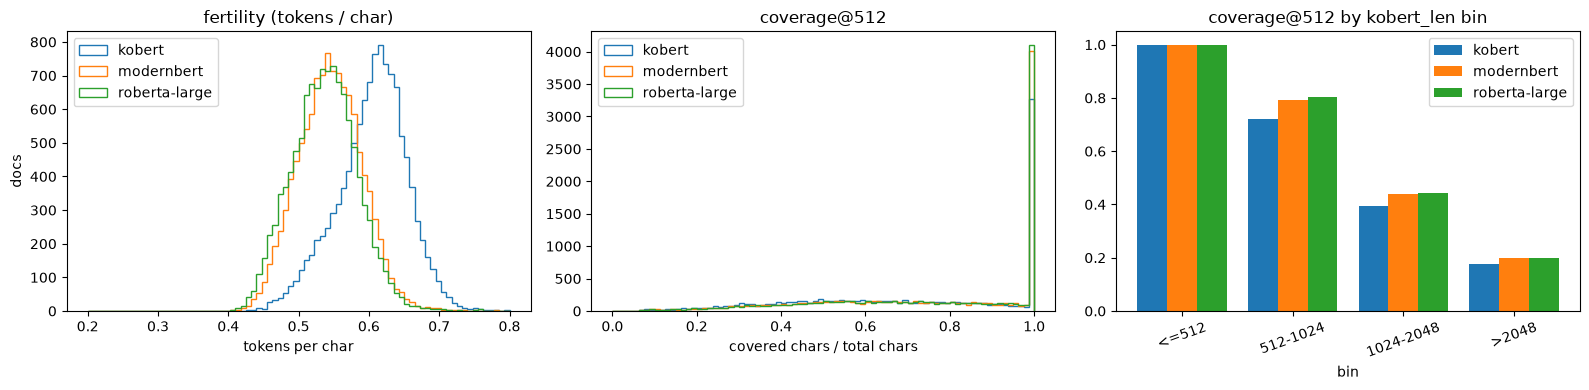

In [26]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for k in models_dict:
    a = A[k]["arr"]
    axes[0].hist(a["n_tok"] / a["n_char"], bins=80, range=(0.2, 0.8), histtype="step", label=k)
    axes[1].hist(cov[k], bins=80, range=(0, 1), histtype="step", label=k)

axes[0].set(title="fertility (tokens / char)", xlabel="tokens per char", ylabel="docs")
axes[1].set(title=f"coverage@{WINDOW}", xlabel="covered chars / total chars")
for ax in axes[:2]:
    ax.legend()

x = np.arange(len(BINS))
for i, k in enumerate(models_dict):
    axes[2].bar(x + (i - 1) * 0.27, [cov[k][length_bin == b].mean() for b in BINS], width=0.27, label=k)
axes[2].set(title=f"coverage@{WINDOW} by kobert_len bin", xticks=x, xlabel="bin")
axes[2].set_xticklabels(BINS, rotation=20)
axes[2].legend()

plt.tight_layout()
plt.show()

## 저장

수치의 SSOT는 `output/tokenizer_analysis.json`. 해석은 `docs/experiments/modernbert-comparison.md` 「길이 vs 모델 분해」에 인용한다.

In [27]:
result = {
    "split": SPLIT,
    "n_docs": len(texts),
    "window": WINDOW,
    "fields": config["fields"],
    "tokenizers": {m["arch"]: {"name": m["tokenizer"], "revision": m["tok_rev"]} for m in MODELS},
    "bin_counts": {b: int((length_bin == b).sum()) for b in BINS},
    "fertility": fertility,
    "pairwise_seq_len_diff": pairwise,
    "coverage": coverage,
    "degradation": degradation,
}

out = config["out_path"] / "tokenizer_analysis.json"
out.write_text(json.dumps(result, ensure_ascii=False, indent=2), encoding="utf-8")
print(f"saved: {out}")

saved: C:\workspace\patent_disc\output\tokenizer_analysis.json
